In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-le

In [3]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

## 1) Load datasets

_ctl_

In [4]:
# ta_sfc_ctl
data_path_ctl = "/scratch/m/m300948/test_04/pre_cape_cin_calculation"
file_pattern = data_path_ctl + "/ta_sfc_ctl_6plus1_correct_*.nc"

# 1. 파일 리스트 가져오기 
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬

# 2. List of specific files to load
#file_list = [
#    f"{data_path_ctl}/ta_sfc_ctl_6plus1_correct_01.nc",
#    f"{data_path_ctl}/ta_sfc_ctl_6plus1_correct_02.nc",
#    f"{data_path_ctl}/ta_sfc_ctl_6plus1_correct_12.nc"
#]


concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.ta.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
ta_sfc_ctl_6plus1 = xr.DataArray(concat_array, dims=["location"])


In [5]:
# qa_sfc_ctl
data_path_ctl = "/scratch/m/m300948/test_04/pre_cape_cin_calculation"
file_pattern = data_path_ctl + "/qa_sfc_ctl_6plus1_correct_*.nc"

# 파일 리스트 가져오기
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬
# 2. List of specific files to load
#file_list = [
#    f"{data_path_ctl}/qa_sfc_ctl_6plus1_correct_01.nc",
#    f"{data_path_ctl}/qa_sfc_ctl_6plus1_correct_02.nc",
#    f"{data_path_ctl}/qa_sfc_ctl_6plus1_correct_12.nc"
#]

concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.hus.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
qa_sfc_ctl_6plus1 = xr.DataArray(concat_array, dims=["location"])

In [23]:
# cape_ctl
data_path_ctl = "/scratch/m/m300948/test_04/pre_cape_cin_calculation"
file_pattern = data_path_ctl + "/cape_ctl_6plus1_correct_*.nc"

# 2. List of specific files to load
#file_list = [
#    f"{data_path_ctl}/cape_ctl_6plus1_correct_07.nc",
#    f"{data_path_ctl}/cape_ctl_6plus1_correct_08.nc",
#    f"{data_path_ctl}/cape_ctl_6plus1_correct_09.nc"
#]
# 파일 리스트 가져오기
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬

concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.__xarray_dataarray_variable__.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
cape_ctl_6plus1 = xr.DataArray(concat_array, dims=["location"])

In [6]:
# cin_ctl
data_path_ctl = "/scratch/m/m300948/test_04/pre_cape_cin_calculation"
file_pattern = data_path_ctl + "/cin_ctl_6plus1_correct_*.nc"

# 1. 파일 리스트 가져오기
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬

# 2. List of specific files to load
#file_list = [
#    f"{data_path_ctl}/cin_ctl_6plus1_correct_01.nc",
#    f"{data_path_ctl}/cin_ctl_6plus1_correct_02.nc",
#    f"{data_path_ctl}/cin_ctl_6plus1_correct_12.nc"
#]

concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.__xarray_dataarray_variable__.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
cin_ctl_6plus1 = xr.DataArray(concat_array, dims=["location"])

_def_

In [7]:
# ta_sfc_def
data_path_def = "/scratch/m/m300948/def_100/pre_cape_cin_calculation"
file_pattern = data_path_def + "/ta_sfc_def_6plus1_correct_*.nc"

# 1. 파일 리스트 가져오기
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬

# 2. List of specific files to load
#file_list = [
#    f"{data_path_def}/ta_sfc_def_6plus1_correct_01.nc",
#    f"{data_path_def}/ta_sfc_def_6plus1_correct_02.nc",
#    f"{data_path_def}/ta_sfc_def_6plus1_correct_12.nc"
#]

concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.ta.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
ta_sfc_def_6plus1 = xr.DataArray(concat_array, dims=["location"])

In [8]:
# qa_sfc_def
data_path_def = "/scratch/m/m300948/def_100/pre_cape_cin_calculation"
file_pattern = data_path_def + "/qa_sfc_def_6plus1_correct_*.nc"

# 1. 파일 리스트 가져오기
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬

# 2. List of specific files to load
#file_list = [
#    f"{data_path_def}/qa_sfc_def_6plus1_correct_01.nc",
#    f"{data_path_def}/qa_sfc_def_6plus1_correct_02.nc",
#    f"{data_path_def}/qa_sfc_def_6plus1_correct_12.nc"
#]

concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.hus.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
qa_sfc_def_6plus1 = xr.DataArray(concat_array, dims=["location"])

In [24]:
# cape_def
data_path_def = "/scratch/m/m300948/def_100/pre_cape_cin_calculation"
file_pattern = data_path_def + "/cape_def_6plus1_correct_*.nc"

# 파일 리스트 가져오기
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬

# 2. List of specific files to load
#file_list = [
#    f"{data_path_def}/cape_def_6plus1_correct_07.nc",
#    f"{data_path_def}/cape_def_6plus1_correct_08.nc",
#    f"{data_path_def}/cape_def_6plus1_correct_09.nc"
#]

concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.__xarray_dataarray_variable__.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
cape_def_6plus1 = xr.DataArray(concat_array, dims=["location"])

In [9]:
# cin_def
data_path_def = "/scratch/m/m300948/def_100/pre_cape_cin_calculation"
file_pattern = data_path_def + "/cin_def_6plus1_correct_*.nc"

# 1. 파일 리스트 가져오기
file_list = sorted(glob.glob(file_pattern))  # 파일 이름 정렬

# 2. List of specific files to load
#file_list = [
#    f"{data_path_def}/cin_def_6plus1_correct_01.nc",
#    f"{data_path_def}/cin_def_6plus1_correct_02.nc",
#    f"{data_path_def}/cin_def_6plus1_correct_12.nc"
#]

concat_list = []  # 데이터를 저장할 리스트

for file in file_list:
    ds = xr.open_dataset(file)  # 파일 로드
    concat_list.append(ds.__xarray_dataarray_variable__.values)  # NumPy 배열로 변환 후 저장

# NumPy로 한 번에 연결 (메모리 효율적)
concat_array = np.concatenate(concat_list, axis=0)
# Xarray로 변환
cin_def_6plus1 = xr.DataArray(concat_array, dims=["location"])

## 2) Plot PDF 

_Flattens the data_

In [25]:
cape_ctl_f = cape_ctl_6plus1.values.flatten()
cape_def_f = cape_def_6plus1.values.flatten()

In [10]:
cin_ctl_f = cin_ctl_6plus1.values.flatten()
cin_def_f = cin_def_6plus1.values.flatten()

/tmp/ipykernel_1619997/3675172507.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('PiYG')


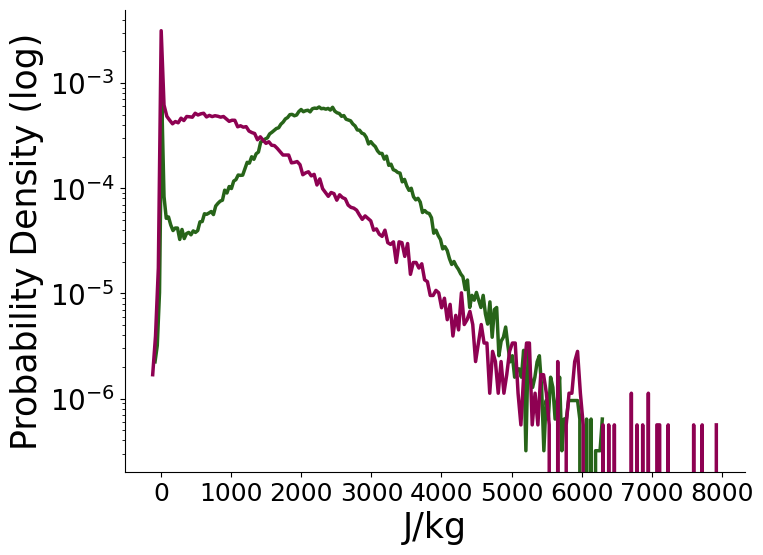

In [26]:
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(cape_ctl_f, bins=200, density=True)
pdf_def, bin_edges_def = np.histogram(cape_def_f, bins=200, density=True)

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))

plt.plot(bin_centers_ctl, pdf_ctl, label='CTL', color=right, linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='DEF', color=left, linewidth=2.5)

# Set labels and title
plt.xlabel('J/kg', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
plt.yscale('log')

#plt.xlim(0, 425)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()

/tmp/ipykernel_1619997/963157413.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('PiYG')


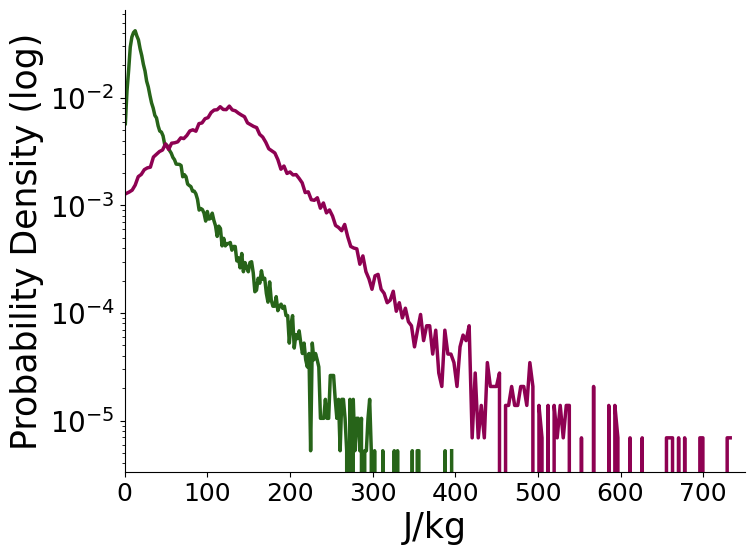

In [16]:
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(-cin_ctl_f_woz, bins=200, density=True)
pdf_def, bin_edges_def = np.histogram(-cin_def_f_woz, bins=200, density=True)

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))

plt.plot(bin_centers_ctl, pdf_ctl, label='CTL', color=right, linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='DEF', color=left, linewidth=2.5)

# Set labels and title
plt.xlabel('J/kg', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=18)
plt.yticks(fontsize=20)
plt.yscale('log')

plt.xlim(0, 750)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()

## CAPE with qa and ta

In [17]:
ta_ctl_f = ta_sfc_ctl_6plus1.values.flatten()
qa_ctl_f = qa_sfc_ctl_6plus1.values.flatten()

In [18]:
ta_def_f = ta_sfc_def_6plus1.values.flatten()
qa_def_f = qa_sfc_def_6plus1.values.flatten()

### CAPE

/tmp/ipykernel_1619997/2855123718.py:23: RuntimeWarning: invalid value encountered in divide
  avg_cape = cape_2d / counts


270.14404432132966 18707.0 0.0


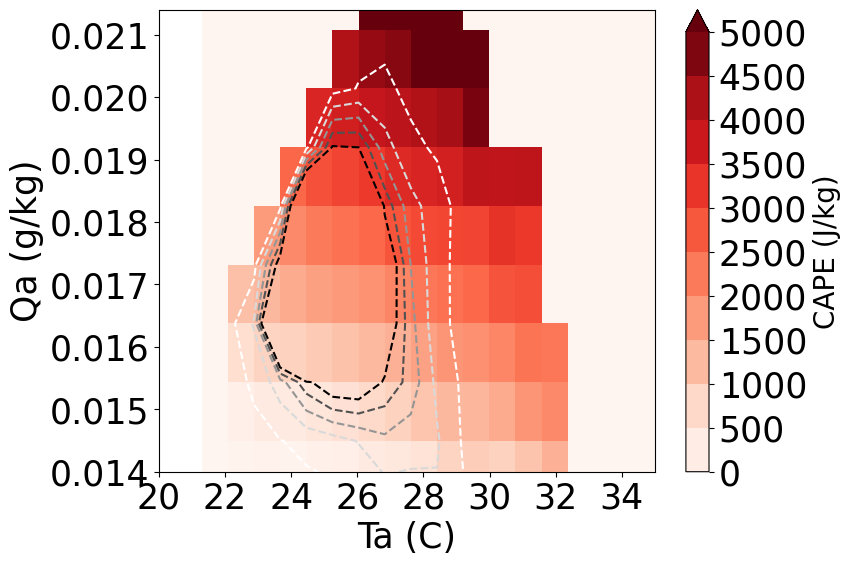

In [27]:
# Step 2: Mask to remove any NaN values in any of the three datasets
#mask = ~np.isnan(cape_ctl_wet_mask_flat) & ~np.isnan(ta_ctl_wet_mask_flat) & ~np.isnan(qa_ctl_wet_mask_flat)

#cape_clean = cape_ctl_wet_mask_flat[mask]
#ta_clean = ta_ctl_wet_mask_flat[mask]
#qa_clean = qa_ctl_wet_mask_flat[mask]

cape_clean = cape_ctl_f
ta_clean = ta_ctl_f
qa_clean = qa_ctl_f
# Step 3: Create 2D histogram binning the qa and ta, using capeitation as color
# ctline number of bins for x and y (qa and ta)
x_bins = np.linspace(np.nanmin(ta_clean), np.nanmax(ta_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(qa_clean), np.nanmax(qa_clean), 20)

# Create 2D histogram for binned capeitation data (cape_2d: summation of all cape values in each bin)
cape_2d, x_edges, y_edges = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins], weights=cape_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs (average cape value in the bins of ta and qa)
avg_cape = cape_2d / counts
avg_cape[np.isnan(avg_cape)] = 0  # Replace NaNs with 0 if needed
#avg_cape[avg_cape < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing capeitation
plt.pcolormesh(x_edges, y_edges, avg_cape.T, shading='auto', cmap='Reds', vmin=0, vmax=5000)
bounds = np.linspace(0, 5000, 11)
cbar = plt.colorbar(extend='max', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('CAPE (J/kg)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(100, 1000, 5)  # Define your desired contour levels
print(np.mean(counts), np.max(counts), np.min(counts))
# Plot contour lines for the counts (frequency of cape)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, cmap='Greys', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('Ta (C)', fontsize=25)
plt.ylabel('Qa (g/kg)', fontsize=25)
#plt.title('capeitation Based on U600-U925 and qa', fontsize=14)
plt.ylim(0.014, 0.0214)
plt.xlim(20, 35)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()

/tmp/ipykernel_3571580/1203354052.py:23: RuntimeWarning: invalid value encountered in divide
  avg_cape = cape_2d / counts


66.26315789473684 1036.0 0.0


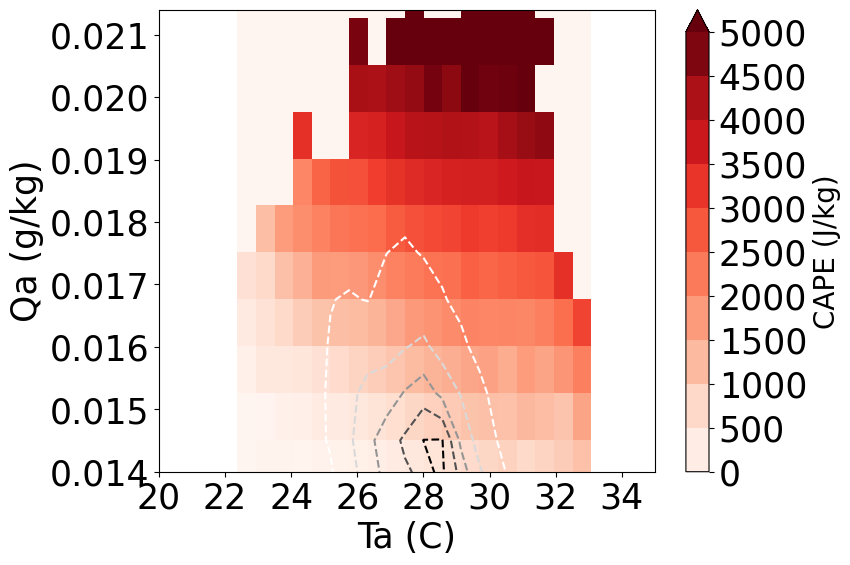

In [89]:
# Step 2: Mask to remove any NaN values in any of the three datasets
#mask = ~np.isnan(cape_def_wet_mask_flat) & ~np.isnan(ta_def_wet_mask_flat) & ~np.isnan(qa_def_wet_mask_flat)

#cape_clean = cape_def_wet_mask_flat[mask]
#ta_clean = ta_def_wet_mask_flat[mask]
#qa_clean = qa_def_wet_mask_flat[mask]

cape_clean = cape_def_f
ta_clean = ta_def_f
qa_clean = qa_def_f
# Step 3: Create 2D histogram binning the qa and ta, using capeitation as color
# define number of bins for x and y (qa and ta)
x_bins = np.linspace(np.nanmin(ta_clean), np.nanmax(ta_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(qa_clean), np.nanmax(qa_clean), 20)

# Create 2D histogram for binned capeitation data
cape_2d, x_edges, y_edges = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins], weights=cape_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs
avg_cape = cape_2d / counts
avg_cape[np.isnan(avg_cape)] = 0  # Replace NaNs with 0 if needed
#avg_cape[avg_cape < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing capeitation
plt.pcolormesh(x_edges, y_edges, avg_cape.T, shading='auto', cmap='Reds', vmin=0, vmax=5000)
bounds = np.linspace(0, 5000, 11)
cbar = plt.colorbar(extend='max', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('CAPE (J/kg)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(100, 1000, 5)  # Define your desired contour levels
print(np.mean(counts), np.max(counts), np.min(counts))
# Plot contour lines for the counts (frequency of W and qa)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, cmap='Greys', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('Ta (C)', fontsize=25)
plt.ylabel('Qa (g/kg)', fontsize=25)
#plt.title('capeitation Based on U600-U925 and qa', fontsize=14)
plt.ylim(0.014, 0.0214)
plt.xlim(20, 35)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()

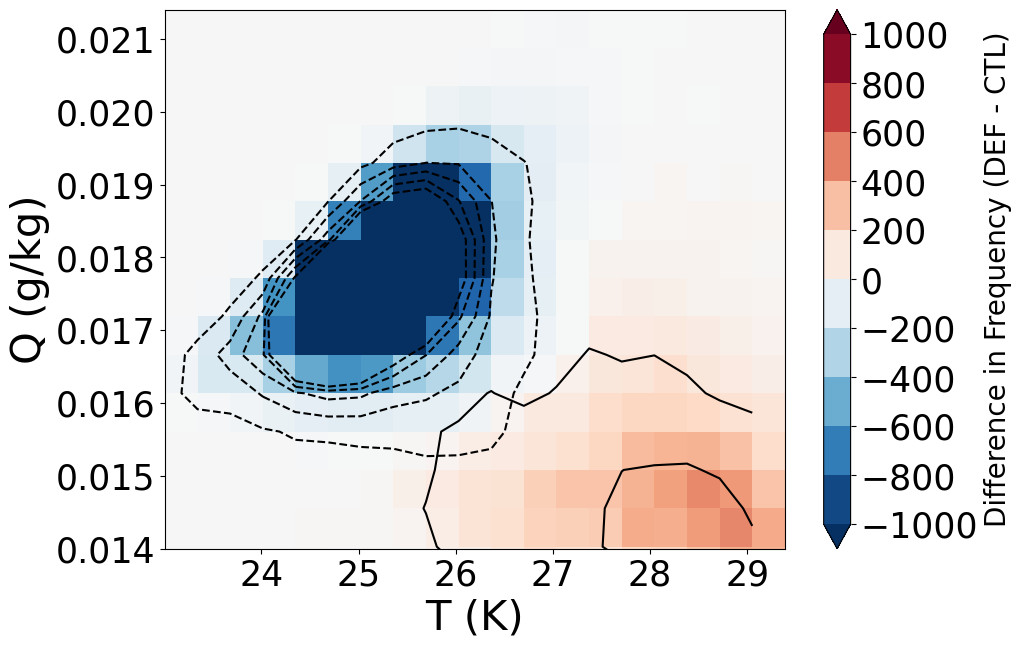

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Mask to remove any NaN values in any of the three datasets
#mask_ctl = ~np.isnan(ta_ctl_wet_mask_flat) & ~np.isnan(qa_ctl_wet_mask_flat) & ~np.isnan(cape_ctl_wet_mask_flat)
#mask_def = ~np.isnan(ta_def_wet_mask_flat) & ~np.isnan(qa_def_wet_mask_flat) & ~np.isnan(cape_def_wet_mask_flat)

U_diff_clean_ctl = ta_ctl_f
TCW_clean_ctl = qa_ctl_f
Precip_clean_ctl = cape_ctl_f

U_diff_clean_def = ta_def_f
TCW_clean_def = qa_def_f
Precip_clean_def = cape_def_f

# Step 3: Create a 2D histogram binning the TCW and U_diff, based on event frequency
x_bins = np.linspace(np.nanmin(U_diff_clean_ctl), np.nanmax(U_diff_clean_ctl), 20)
y_bins = np.linspace(np.nanmin(TCW_clean_ctl), np.nanmax(TCW_clean_ctl), 20)

# Create 2D histograms counting the number of events in each bin
counts_ctl, x_edges_ctl, y_edges_ctl = np.histogram2d(U_diff_clean_ctl, TCW_clean_ctl, bins=[x_bins, y_bins])
counts_def, x_edges_def, y_edges_def = np.histogram2d(U_diff_clean_def, TCW_clean_def, bins=[x_bins, y_bins])

# Calculate the difference between DEF and CTL
counts_diff = counts_def - counts_ctl

# Step 4: Plot the difference using a diverging color map (RdBu)
plt.figure(figsize=(10, 7))

# Plot the difference between DEF and CTL
m = plt.pcolormesh(x_edges_ctl, y_edges_ctl, counts_diff.T, shading='auto', cmap='RdBu_r', vmin=-1000, vmax=1000 ) #vmin=-np.max(np.abs(counts_diff)), vmax=np.max(np.abs(counts_diff)))

# Optional: Overlay contours for CTL to provide reference points
plt.contour(x_edges_ctl[:-1], y_edges_ctl[:-1], counts_ctl.T, levels=np.linspace(100, 1000, 5), colors='black', linewidths=1.5, linestyles='--')
plt.contour(x_edges_def[:-1], y_edges_def[:-1], counts_def.T, levels=np.linspace(100, 1000, 5), colors='black', linewidths=1.5, linestyles='-')

# Add a colorbar for the difference plot
# Add colorbar for precipitation
bounds = np.linspace(-1000, 1000, 11)
cbar = plt.colorbar(m, extend='both', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('Difference in Frequency (DEF - CTL)', fontsize=20)

# Set axis labels
plt.xlabel('T (K)', fontsize=30)
plt.ylabel('Q (g/kg)', fontsize=30)
plt.ylim(0.014, 0.0214)

# Set tick size for the plot
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()


In [ ]:
print(np.nanmax(ta_ctl_f))
print(np.nanmax(ta_def_f))

29.024689
29.091003


/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-le

### CIN

In [32]:
print(np.shape(cin_ctl_f), np.shape(cin_def_f), np.shape(ta_ctl_f), np.shape(ta_def_f), np.shape(qa_ctl_f), np.shape(qa_def_f))

(97522,) (43958,) (97522,) (43958,) (10575,) (43958,)


In [41]:
print(np.nanmin(cin_ctl_f), np.nanmin(cin_def_f))

-396.7152310186553 -734.541885845684


/tmp/ipykernel_1619997/1975180846.py:23: RuntimeWarning: invalid value encountered in divide
  avg_cin = cin_2d / counts


270.14404432132966 18707.0 0.0


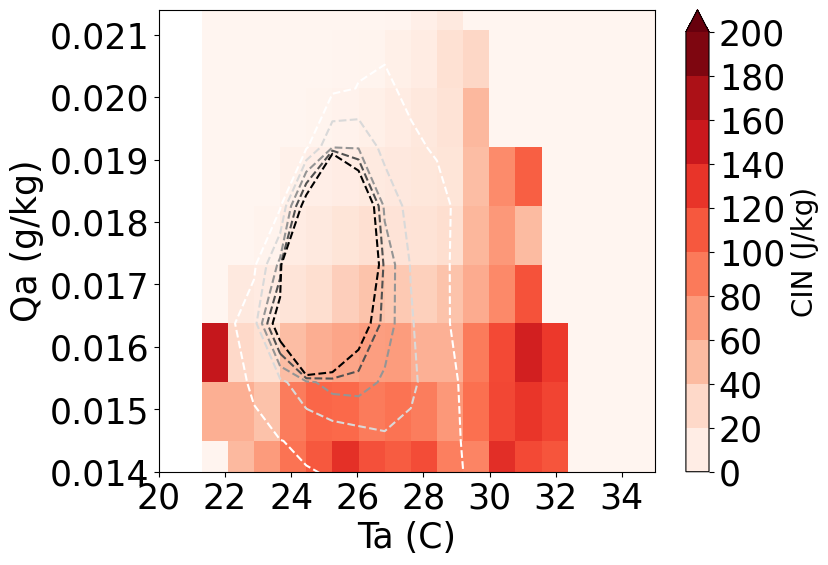

In [22]:
# Step 2: Mask to remove any NaN values in any of the three datasets
#mask = ~np.isnan(cin_ctl_wet_mask_flat) & ~np.isnan(ta_ctl_wet_mask_flat) & ~np.isnan(qa_ctl_wet_mask_flat)

#cin_clean = cin_ctl_wet_mask_flat[mask]
#ta_clean = ta_ctl_wet_mask_flat[mask]
#qa_clean = qa_ctl_wet_mask_flat[mask]

cin_clean = -cin_ctl_f
ta_clean = ta_ctl_f
qa_clean = qa_ctl_f
# Step 3: Create 2D histogram binning the qa and ta, using cinitation as color
# ctline number of bins for x and y (qa and ta)
x_bins = np.linspace(np.nanmin(ta_clean), np.nanmax(ta_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(qa_clean), np.nanmax(qa_clean), 20)

# Create 2D histogram for binned cinitation data (cin_2d: summation of all cin values in each bin)
cin_2d, x_edges, y_edges = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins], weights=cin_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs (average cin value in the bins of ta and qa)
avg_cin = cin_2d / counts
avg_cin[np.isnan(avg_cin)] = 0  # Replace NaNs with 0 if needed
#avg_cin[avg_cin < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing cinitation
plt.pcolormesh(x_edges, y_edges, avg_cin.T, shading='auto', cmap='Reds', vmin=0, vmax=200)
bounds = np.linspace(0, 200, 11)
cbar = plt.colorbar(extend='max', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('CIN (J/kg)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(100, 2000, 5)  # Define your desired contour levels
print(np.mean(counts), np.max(counts), np.min(counts))
# Plot contour lines for the counts (frequency of cin)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, cmap='Greys', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('Ta (C)', fontsize=25)
plt.ylabel('Qa (g/kg)', fontsize=25)
#plt.title('cinitation Based on U600-U925 and qa', fontsize=14)
plt.ylim(0.014, 0.0214)
plt.xlim(20, 35)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()

/tmp/ipykernel_3479550/534738255.py:23: RuntimeWarning: invalid value encountered in divide
  avg_cin = cin_2d / counts


121.76731301939058 3037.0 0.0


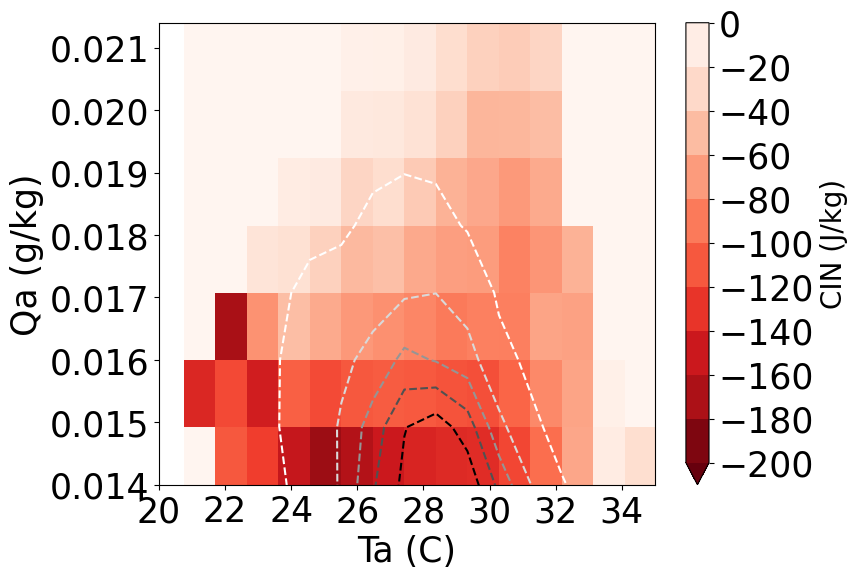

In [62]:
# Step 2: Mask to remove any NaN values in any of the three datasets
#mask = ~np.isnan(cin_def_wet_mask_flat) & ~np.isnan(ta_def_wet_mask_flat) & ~np.isnan(qa_def_wet_mask_flat)

#cin_clean = cin_def_wet_mask_flat[mask]
#ta_clean = ta_def_wet_mask_flat[mask]
#qa_clean = qa_def_wet_mask_flat[mask]

cin_clean = cin_def_f
ta_clean = ta_def_f
qa_clean = qa_def_f
# Step 3: Create 2D histogram binning the qa and ta, using cinitation as color
# define number of bins for x and y (qa and ta)
x_bins = np.linspace(np.nanmin(ta_clean), np.nanmax(ta_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(qa_clean), np.nanmax(qa_clean), 20)

# Create 2D histogram for binned cinitation data (cin_2d: summation of all cin values in each bin)
cin_2d, x_edges, y_edges = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins], weights=cin_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs (average cin value in the bins of ta and qa)
avg_cin = cin_2d / counts
avg_cin[np.isnan(avg_cin)] = 0  # Replace NaNs with 0 if needed
#avg_cin[avg_cin < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing cinitation
plt.pcolormesh(x_edges, y_edges, avg_cin.T, shading='auto', cmap='Reds_r', vmin=-200, vmax=0)
bounds = np.linspace(-200, 0, 11)
cbar = plt.colorbar(extend='min', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('CIN (J/kg)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(100, 2000, 5)  # Define your desired contour levels
print(np.mean(counts), np.max(counts), np.min(counts))
# Plot contour lines for the counts (frequency of cin)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, cmap='Greys', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('Ta (C)', fontsize=25)
plt.ylabel('Qa (g/kg)', fontsize=25)
#plt.title('cinitation Based on U600-U925 and qa', fontsize=14)
plt.ylim(0.014, 0.0214)
plt.xlim(20, 35)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()